In [1]:
import pandas as pd
import json
import requests
import re

def print_full(x):
    with pd.option_context('display.max_columns', None):
        display(x)


### This notebook contains one class:
* MT - Performs calculations/analysis functions on the scraped MT data

### The data that MT class uses:
* mt-sectors - A list of sectors, scraped from the MT sector list
* mt-industries - A list of industries, scraped from the MT industry list
* mt-tickers - A list of all tickers known by MT, with their sector and industry
* mt-prices - The tickers and historical prices, date, end of day price and volume traded that day

* mt-balance-sheet-quarterly - Balance sheet
* mt-income-statement-quarterly - Income statement
* mt-cash-flow-statement-quarterly - Cashflow statement

### Remove all other cells in this notebook
* Ideas is to include this notebook at the top of any analysis notebook to build on top of MT classes

In [2]:
class MT():

    incq = pd.read_csv('MT/mt-income-statement-quarterly.csv', parse_dates=['Quarter'], dtype={'ticker':'str', '*':'float'}).set_index(['ticker','Quarter'])
    balanceq = pd.read_csv('MT/mt-balance-sheet-quarterly.csv', parse_dates=['Quarter']).set_index(['ticker','Quarter'])
    cfq = pd.read_csv('MT/mt-cash-flow-statement-quarterly.csv', parse_dates=['Quarter']).set_index(['ticker','Quarter'])
    
    prices = pd.read_csv('MT/mt-prices.csv', parse_dates=['timestamp']).set_index(['ticker','timestamp'])
    
    # List of tickers known to MT
    tickers = pd.read_csv('MT/mt-tickers.csv').set_index('ticker')

    # Convenience methods used by all other methods
    # These functions are designed to work with the quarterly report data
    # They expect to receive a column of data, date index, sorted ascending (so final rows are most recent)
    # Most Recent Quarter: returns last item in list, or NA if no data found
    def MRQ(col):
        col = col.dropna()
        if (len(col) > 0):
            return col.iloc[-1]

    # TTM - sum of last 4 quarters
    def TTM(col):
        col = col.dropna()
        if (len(col) > 3):
            return col.iloc[-4:].sum()

    # rollingTTM - rolling sum of four quarters
    def rollingTTM(col):
        return col.dropna().rolling(window=4).sum()

    # rollingMean - rolling mean of four quarters, used to smooth out some fields such as shares outstanding
    def rollingMean(col, period = 4):
        return col.dropna().rolling(window=period).mean()

    # firstQuarter
    # Simply returns the first date for which we have data
    def firstQuarter():
        dates = MT.balanceq.index.get_level_values(1)
        return dates.sort_values()[0]
        
    
    # KEY FIELDS FROM FUNDAMENTAL DATA
    #
    # OVERVIEW
    #
    # Full Overview - returns the entire overview object
    # We don't have this for MT so remove it...
    # Sectors - returns a list of sectors as defined by the MT overview data
    def sectors():
        sectors = pd.read_csv('MT/mt-sectors.csv')
        return list(sectors['name'])

    # Industries - returns a list of industries for a given Sector, or all if no Sector supplied
    def industries(sector=False):
        industries = pd.read_csv('MT/mt-industries.csv')
        if (sector):
            rows = industries[ industries['zacks_x_sector_desc'] == sector]
        else:
            rows = industries
        return list(rows['zacks_x_ind_title'].unique())

    # Sector Tickers - for a given sector return a list of tickers in that sector
    def sectorTickers(sector, prices = False):
        tickerlist = []
        for ind in MT.industries(sector):
            tickerlist.extend(MT.industryTickers(ind) )
        if (prices == True):
            p = MT.prices.index.get_level_values(0)
            tickerlist = list( set(tickerlist).intersection(set(p)) )
        return tickerlist
              
    # Industry Tickers - for a given industry returns a list of tickers in that industry
    # Note: this works ok because all industry names are unique - beware in the event that Sectors have the same Industry (eg 'General' or 'Miscellaneous')
    def industryTickers(industry, prices = False):
        t = MT.tickers[ MT.tickers['zacks_x_ind_desc'] == industry ].index.to_list()
        if (prices == True):
            p = MT.prices.index.get_level_values(0)
            t = list( set(t).intersection(set(p)) )
        return t
                                                                      
    # Company Name - supply the company name for a given ticker
    def companyName(t):
        return MT.tickers.loc[t]['comp_name_2']

    # Ticker Info - returns the company data we have for this ticker
    def tickerInfo(t):
        return MT.tickers.loc[t]
    
    # INCOME STATEMENT
    #
    def incomestatement(tickers):
        return MT.incq.loc[tickers]
    
    # Total Revenue
    def revenue(tickers):
        return MT.incq.loc[tickers]['Revenue'].unstack(level=0).sort_index()
        
    def grossProfit(tickers):
        return MT.incq.loc[tickers]['Gross Profit'].unstack(level=0).sort_index()

    
    # EBITDA
    # according to Macro Trends: Net Income + Depreciation
    # However MT provides it for us in the Income Statement
    def EBITDA(tickers):
        return MT.incq.loc[tickers]['EBITDA'].unstack(level=0).sort_index()

    # EBIT
    # Seems that EBIT is actually just operatingIncome in a lot of cases
    # Don't know why AV reports EBIT as different to Operating Income
    def EBIT(tickers):
        return MT.incq.loc[tickers]['EBIT'].unstack(level=0).sort_index()
    
    # Net Income - bottom line from INCOME STATEMENT
    def netIncome(tickers):
        return MT.incq.loc[tickers]['Net Income'].unstack(level=0).sort_index()
    
    # Operating Income - Income after operational expenses
    def operatingIncome(tickers):
        return MT.incq.loc[tickers]['Operating Income'].unstack(level=0).sort_index()
    
    # Total Shares Outstanding - use for all the per share calculations
    # For MacroTrends this is provided in the Income Statement not the Balance Sheet
    def totalSharesOutstanding(tickers):
        return MT.incq.loc[tickers]['Shares Outstanding'].unstack(level=0).sort_index()

    # BALANCE SHEET
    #
    # balancesheet - returns balance sheet for ticker t (grabs from MT if not already present)
    # t can also be a dictionary with ticker symbol as key and company name as value, allows fetching using company name
    def balancesheet(t):
        
        # mapping for fields in Balance Sheet
        # Maps MT fields to AV fields - not sure why this way round, maybe I just like the way AV doesn't include spaces
        mapping = {'Total Assets': 'totalAssets',
            'Total Current Assets': 'totalCurrentAssets',
            'Cash On Hand': 'cashAndShortTermInvestments',
            'Inventory': 'inventory',
            'Receivables': 'currentNetReceivables',
            'Total Long-Term Assets': 'totalNonCurrentAssets',
            'Property, Plant, And Equipment': 'propertyPlantEquipment',
            'Long-Term Investments': 'longTermInvestments',
            'Other Current Assets': 'otherCurrentAssets',
            'Other Long-Term Assets': 'otherNonCurrrentAssets',
            'Total Liabilities': 'totalLiabilities',
            'Total Current Liabilities': 'totalCurrentLiabilities',
            'Total Long Term Liabilities': 'totalNonCurrentLiabilities',
            'Long Term Debt': 'longTermDebtNoncurrent',
            'Other Non-Current Liabilities': 'otherNonCurrentLiabilities',
            'Share Holder Equity': 'totalShareholderEquity',
            'Retained Earnings (Accumulated Deficit)': 'retainedEarnings',
            'Common Stock Net': 'commonStock'}

        try:
            df = MT.balanceq.loc[t]
            mapped = df[mapping.keys()].rename(columns=mapping)
            
            # Append the number of outstanding shares - MT this appears in the income statement
            mapped['totalSharesOutstanding'] = MT.incq.loc[t]['Basic Shares Outstanding']
            
            return mapped
        
        except:
            return 'Unknown'
        

    # Current Assets: total short-term assets
    def currentAssets(tickers):
        return MT.balanceq.loc[tickers]['Total Current Assets'].unstack(level=0).sort_index()

    # Total Assets: long and short term
    def totalAssets(tickers):
        return MT.balanceq.loc[tickers]['Total Assets'].unstack(level=0).sort_index()
        
    # Inventory - asset value of inventory
    def inventory(tickers):
        return MT.balanceq.loc[tickers]['Inventory'].unstack(level=0).sort_index()

    # Current Liabilities: short-term (less than 1 year) liabilities
    def currentLiabilities(tickers):
        return MT.balanceq.loc[tickers]['Total Current Liabilities'].unstack(level=0).sort_index()

    # Total Liabilities
    def totalLiabilities(tickers):
        return MT.balanceq.loc[tickers]['Total Liabilities'].unstack(level=0).sort_index()

    # current Debt not done yet
    def currentDebt(tickers):
        return AlphaVantage.balanceq.loc[tickers]['currentDebt'].unstack(level=0).sort_index()
        
    # Total Long-Term Debt - used in the debt/equity ratio
    def longtermDebt(tickers):
        return MT.balanceq.loc[tickers]['Long Term Debt'].unstack(level=0).sort_index()

    # Total Shareholder Equity: Shareholder Equity = Assets - Liabilities
    # MacroTrends supplies this in the Balance Sheet
    def totalShareholderEquity(tickers):
        return MT.balanceq.loc[tickers]['Share Holder Equity'].unstack(level=0).sort_index()
    
    def propertyPlantEquipment(tickers):
        return MT.balanceq.loc[tickers]['Property, Plant, And Equipment'].unstack(level=0).sort_index()
    
    # depreciationAmortization - can calculate this by subtracting EBIT from EBITDA, what's left is DA
    # This doesn't seem to work very well...
#     def depreciationAmortization(tickers):
#         return MT.EBITDA(tickers) - MT.EBIT(tickers)

    
    # CASH-FLOW STATEMENT
    #
    def cashflowstatement(tickers):
        return MT.cfc.loc[tickers]
    
    # Operating Cashflow: Similar to income statement cash from operations
    def operatingCashflow(tickers):
        return MT.cfq.loc[tickers]['Cash Flow From Operating Activities'].unstack(level=0).sort_index()
    
    # Capital Expenditures: Cash spent on stuff (not long-term property, factories)
    def capitalExpenditures(tickers):
        return MT.cfq.loc[tickers]['Net Change In Property, Plant, And Equipment'].unstack(level=0).sort_index()


    # MAGIC FORMULA DATA
    # 
    # netFixedAssets we don't have depreciation/amortization so just use property,plant,equipment
    def netFixedAssets(tickers):
        ppe = MT.propertyPlantEquipment(tickers)
        #dep = Ratios.depreciationAmortization(tickers)
        #return ppe + dep
        return ppe
    
    # workingCapital we don't have very fine-grained liabilities so just use currentLiabilites
    def workingCapital(tickers):
        ar = MT.balanceq.loc[tickers]['Receivables'].unstack(level=0).sort_index()
        inv = MT.balanceq.loc[tickers]['Inventory'].unstack(level=0).sort_index()
        other = MT.balanceq.loc[tickers]['Other Current Assets'].unstack(level=0).sort_index()
        liab = MT.balanceq.loc[tickers]['Total Current Liabilities'].unstack(level=0).sort_index()
        return (ar + inv + other) - liab

    # Combining with Price Data
    #
    # Price Ratio - special function for aligning prices with quarterly numbers
    def priceRatio(col):
        tickers = col.columns
        p = MT.prices.loc[tickers]['c'].unstack(level=0).sort_index(ascending=True)
        ret = pd.DataFrame()
        for ticker in tickers:
            m = col[[ticker]].merge(p[[ticker]], how='outer', left_index=True, right_index=True)
            m.iloc[:,1].ffill(inplace=True)
            m.dropna(axis=0, subset=[m.columns[0]], inplace=True)
            ret[ticker] = m.iloc[:,1] / m.iloc[:,0]
        return ret.dropna(how='all')

    
    # EARNINGS
    #
    # Earnings Per Share
    def eps(tickers):
        return MT.incq.loc[tickers]['EPS - Earnings Per Share'].unstack(level=0).sort_index()
    
    
    # Some other key figures that will likely always be needed
    #
    # closingPrice - just return the adjusted closing prices we have
    def closingPrice(tickers):
        return MT.prices.loc[tickers]['c'].unstack(level=0).sort_index().fillna(method='ffill')
    
    # Market Cap - Total Shares * Price per share
    def marketCap(tickers):
        tso = MT.totalSharesOutstanding(tickers)
        p = MT.closingPrice(tickers)
        ret = pd.DataFrame()
        for ticker in tickers:
            m = tso[[ticker]].merge(p[[ticker]], how='outer', left_index=True, right_index=True)
            m.iloc[:,1].fillna(method='ffill', inplace=True)
            m.dropna(axis=0, subset=[m.columns[0]], inplace=True)
            # Since dates can be off we need to keep merging each new column
            x = m.iloc[:,1] * m.iloc[:,0]
            x.name = ticker
            ret = ret.merge(x, how='outer', left_index=True, right_index=True)
        return ret.dropna(how='all')



In [3]:
MT.tickers

,zacks_x_ind_desc,comp_name,comp_name_2,price_per_sales,price_book,sector,last_update,status
ticker,,,,,,,,
BRK.A,"Property, Casualty and Title Insurance",berkshire-hathaway,Berkshire Hathaway,2.39,1.47,Finance,2000-01-01,0
BRK.B,"Property, Casualty and Title Insurance",berkshire-hathaway,Berkshire Hathaway,2.34,1.44,Finance,2000-01-01,0
TKOMY,"Property, Casualty and Title Insurance",tokio-marine-holdings,Tokio Marine Holdings,2.88,5.23,Finance,2000-01-01,0
CB,"Property, Casualty and Title Insurance",chubb,Chubb,1.78,1.50,Finance,2000-01-01,0
PGR,"Property, Casualty and Title Insurance",progressive,Progressive,1.48,4.69,Finance,2000-01-01,0
...,...,...,...,...,...,...,...,...
COMX,Computers - Integrated Systems,comtrex-systems,Comtrex Systems,0.00,0.00,Computer and Technology,2023-11-22,1
SLAB,Semiconductor - Analog & Mixed,silicon-laboratories,Silicon Laboratories,4.76,3.48,Computer and Technology,2025-01-03,0
AMX,Wireless - Non-US Providers,"america-movil,-sab-de-cv","America Movil, S.A.B De C.V",1.56,3.11,Computer and Technology,2025-01-03,0


### Plot relative size of each Sector

<AxesSubplot: ylabel='comp_name'>

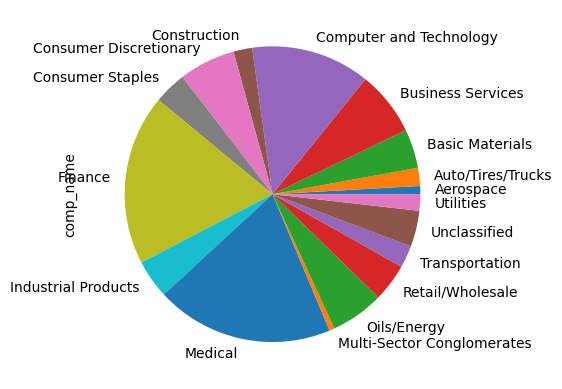

In [4]:
MT.tickers.groupby('sector')['comp_name'].count().plot(kind='pie')

<AxesSubplot: >

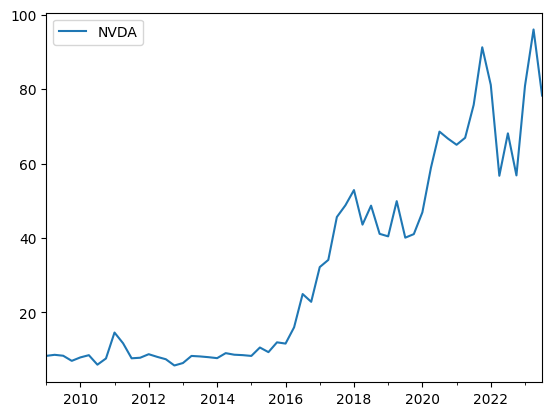

In [5]:
tickers = ['NVDA']
MT.priceRatio(MT.revenue(tickers) / MT.totalSharesOutstanding(tickers)).plot()

In [6]:
tickers = ['NVDA']
MT.priceRatio(MT.revenue(tickers))

,NVDA
2009-01-31,0.003796
2009-04-30,0.003971
2009-07-31,0.003826
2009-10-31,0.003042
2010-01-31,0.003599
2010-04-30,0.003603
2010-07-31,0.002603
2010-10-31,0.003273
2011-01-31,0.006200
2011-04-30,0.004777


### Working with eps data

In [7]:
# Scanning index for missing quarters in the data... attempt to improve data quality
# df = pd.read_csv('MT/mt-income-statement-quarterly.csv', na_filter=False, parse_dates=['Quarter'])
df = pd.read_csv('MT/mt-income-statement-quarterly.csv', na_filter=False, parse_dates=['Quarter']).set_index(['ticker','Quarter'])

def cagr(g):
    g = g.droplevel(level=0).sort_index()
    begin_date = g.index[0]
    print(type(begin_date))
    begin_value = g.loc[begin_date]
    print(begin_value)
    end_date = g.index[-1]
    end_value = g.loc[end_date]
    years = pd.Timedelta(end_date - begin_date)
    growth = end_value - begin_value
    CAGR = (end_value / begin_value)**(1/years)-1
    return CAGR

sample = MT.rollingTTM(MT.revenue(['NVDA']))
sample

ticker,NVDA
Quarter,
2009-01-31,NaN
2009-04-30,NaN
2009-07-31,NaN
2009-10-31,2825.0969
2010-01-31,3326.4450
2010-04-30,3664.0270
2010-07-31,3698.7150
2010-10-31,3639.4210
2011-01-31,3543.3090
